In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [3]:
# ============================================================
# 1. CARREGAR OS DADOS
# ============================================================

dim_hospital = pd.read_parquet('dim_hospital_SP_2024_01.parquet')
dim_municipio = pd.read_parquet('dim_municipio_SP_2024_01.parquet')
dim_tempo = pd.read_parquet('dim_tempo_SP_2024_01.parquet')
fato_internacao = pd.read_parquet('fato_internacao_SP_2024_01.parquet')

In [4]:
print("-" * 60)
print("DADOS CARREGADOS")
print("-" * 60)
print(f"DIM_HOSPITAL    : {len(dim_hospital):,} registros | {len(dim_hospital.columns)} colunas")
print(f"DIM_MUNICIPIO   : {len(dim_municipio):,} registros | {len(dim_municipio.columns)} colunas")
print(f"DIM_TEMPO       : {len(dim_tempo):,} registros | {len(dim_tempo.columns)} colunas")
print(f"FATO_INTERNACAO : {len(fato_internacao):,} registros | {len(fato_internacao.columns)} colunas")

------------------------------------------------------------
DADOS CARREGADOS
------------------------------------------------------------
DIM_HOSPITAL    : 1,404 registros | 17 colunas
DIM_MUNICIPIO   : 645 registros | 6 colunas
DIM_TEMPO       : 1,213 registros | 7 colunas
FATO_INTERNACAO : 1,524,916 registros | 23 colunas


In [5]:
# ============================================================
# 2. DATASET UNIFICADO
# ============================================================

# Juntar todas as tabelas em um único dataset para análise
df = fato_internacao.merge(
    dim_hospital[['id_hospital', 'nome_municipio_hospital', 'leitos_totais', 
                  'porte_hospitalar', 'alta_complexidade', 'uf_hospital']],
    on='id_hospital',
    how='left'
).merge(
    dim_municipio[['codigo_municipio', 'nome_municipio', 'uf', 'estado']],
    left_on='codigo_municipio_paciente',
    right_on='codigo_municipio',
    how='left'
)

print("\n" + "-" * 60)
print("DATASET UNIFICADO")
print("-" * 60)
print(f"Total de registros: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")
print(f"Colunas: {df.columns.tolist()}")



------------------------------------------------------------
DATASET UNIFICADO
------------------------------------------------------------
Total de registros: 1,524,916
Total de colunas: 32
Colunas: ['internacao_id', 'id_hospital', 'codigo_municipio_paciente', 'tempo_id', 'codigo_diagnostico', 'data_internacao', 'data_saida', 'valor_procedimento', 'dias_internacao', 'paciente_viajou', 'nome_municipio_paciente', 'uf_paciente', 'estado_paciente', 'latitude_paciente', 'longitude_paciente', 'nome_municipio_hospital_x', 'latitude_hospital', 'longitude_hospital', 'distancia_estimada_km', 'ano_competencia', 'mes_competencia', 'dia_semana', 'tipo_dia', 'nome_municipio_hospital_y', 'leitos_totais', 'porte_hospitalar', 'alta_complexidade', 'uf_hospital', 'codigo_municipio', 'nome_municipio', 'uf', 'estado']


In [6]:
# ============================================================
# 3. DICIONÁRIO DE DADOS
# ============================================================

dicionario = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.values,
    'Nulos': df.isna().sum().values,
    '% Nulos': (df.isna().sum() / len(df) * 100).values,
    'Valores Únicos': df.nunique().values,
    'Exemplo': [df[col].dropna().iloc[0] if df[col].notna().sum() > 0 else 'N/A' for col in df.columns]
})

print("\n" + "-" * 60)
print("DICIONÁRIO DE DADOS")
print("-" * 60)
print(dicionario.to_string())



------------------------------------------------------------
DICIONÁRIO DE DADOS
                       Coluna            Tipo  Nulos   % Nulos  Valores Únicos                   Exemplo
0               internacao_id           int64      0  0.000000         1524916                         1
1                 id_hospital          object      0  0.000000             616                   2087219
2   codigo_municipio_paciente          object      0  0.000000            1321                    350960
3                    tempo_id           int64      0  0.000000            1213                         1
4          codigo_diagnostico          object      0  0.000000            5513                      K590
5             data_internacao  datetime64[ns]      0  0.000000            1213       2024-01-28 00:00:00
6                  data_saida  datetime64[ns]      0  0.000000             184       2024-01-30 00:00:00
7          valor_procedimento         float64      0  0.000000           30350

In [7]:
# ============================================================
# 4. ANÁLISE DESCRITIVA
# ============================================================

# 4.1 Variáveis Numéricas
variaveis_numericas = ['dias_internacao', 'valor_procedimento', 'leitos_totais', 
                       'latitude_paciente', 'longitude_paciente', 'distancia_estimada_km']

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("=" * 60)

for var in variaveis_numericas:
    if var in df.columns and df[var].notna().sum() > 0:
        print(f"\n--- {var.upper()} ---")
        print(f"Total de registros: {df[var].notna().sum():,}")
        print(f"Média: {df[var].mean():.2f}")
        print(f"Mediana: {df[var].median():.2f}")
        print(f"Desvio Padrão: {df[var].std():.2f}")
        print(f"Mínimo: {df[var].min():.2f}")
        print(f"Máximo: {df[var].max():.2f}")
        print(f"Q1 (25%): {df[var].quantile(0.25):.2f}")
        print(f"Q3 (75%): {df[var].quantile(0.75):.2f}")


ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS

--- DIAS_INTERNACAO ---
Total de registros: 1,524,916
Média: 13.94
Mediana: 3.00
Desvio Padrão: 156.33
Mínimo: 0.00
Máximo: 5874.00
Q1 (25%): 2.00
Q3 (75%): 8.00

--- VALOR_PROCEDIMENTO ---
Total de registros: 1,524,916
Média: 237.32
Mediana: 45.00
Desvio Padrão: 1162.35
Mínimo: 0.00
Máximo: 138727.26
Q1 (25%): 11.24
Q3 (75%): 158.67

--- LEITOS_TOTAIS ---
Total de registros: 1,524,916
Média: 302.96
Mediana: 214.00
Desvio Padrão: 298.12
Mínimo: 1.00
Máximo: 1543.00
Q1 (25%): 138.00
Q3 (75%): 327.00

--- LATITUDE_PACIENTE ---
Total de registros: 1,524,916
Média: -22.66
Mediana: -23.30
Desvio Padrão: 2.44
Mínimo: -25.01
Máximo: 0.00
Q1 (25%): -23.53
Q3 (75%): -22.34

--- LONGITUDE_PACIENTE ---
Total de registros: 1,524,916
Média: -46.97
Mediana: -46.85
Desvio Padrão: 4.84
Mínimo: -53.06
Máximo: 0.00
Q1 (25%): -47.89
Q3 (75%): -46.64

--- DISTANCIA_ESTIMADA_KM ---
Total de registros: 1,524,916
Média: 13.45
Mediana: 0.00
Desvio Padrão: 35.29

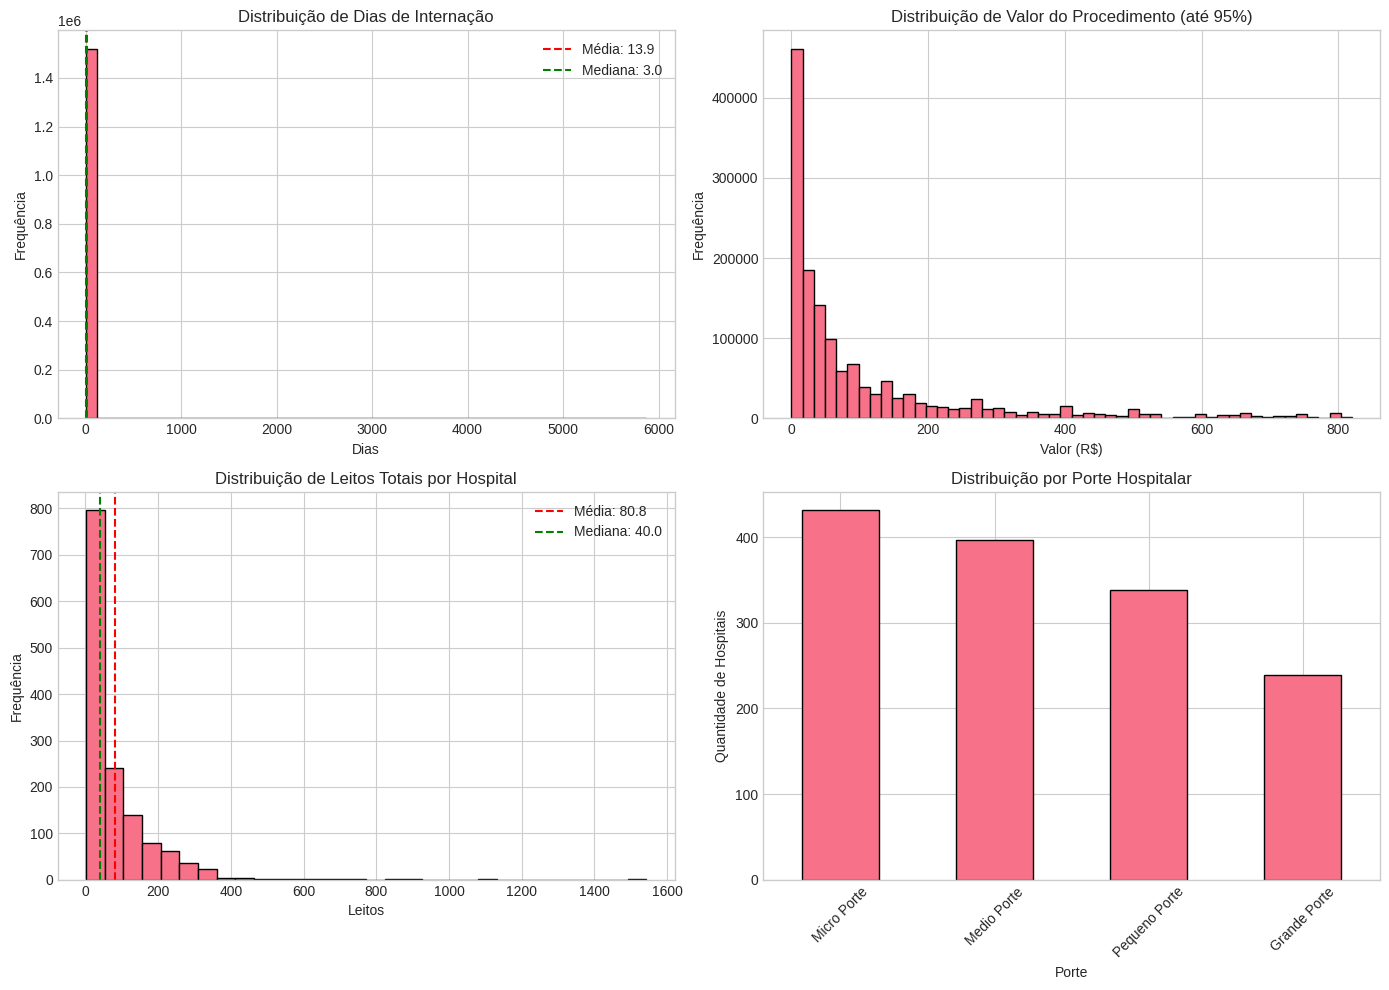

In [9]:
# ============================================================
# 5. DISTRIBUIÇÃO DAS VARIÁVEIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 Dias de Internação
ax = axes[0, 0]
df['dias_internacao'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribuição de Dias de Internação')
ax.set_xlabel('Dias')
ax.set_ylabel('Frequência')
ax.axvline(df['dias_internacao'].mean(), color='red', linestyle='--', label=f'Média: {df["dias_internacao"].mean():.1f}')
ax.axvline(df['dias_internacao'].median(), color='green', linestyle='--', label=f'Mediana: {df["dias_internacao"].median():.1f}')
ax.legend()

# 5.2 Valor do Procedimento (limitado a 95% para visualização)
ax = axes[0, 1]
valor_limite = df['valor_procedimento'].quantile(0.95)
df[df['valor_procedimento'] <= valor_limite]['valor_procedimento'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribuição de Valor do Procedimento (até 95%)')
ax.set_xlabel('Valor (R$)')
ax.set_ylabel('Frequência')

# 5.3 Leitos Totais
ax = axes[1, 0]
dim_hospital['leitos_totais'].hist(bins=30, ax=ax, edgecolor='black')
ax.set_title('Distribuição de Leitos Totais por Hospital')
ax.set_xlabel('Leitos')
ax.set_ylabel('Frequência')
ax.axvline(dim_hospital['leitos_totais'].mean(), color='red', linestyle='--', label=f'Média: {dim_hospital["leitos_totais"].mean():.1f}')
ax.axvline(dim_hospital['leitos_totais'].median(), color='green', linestyle='--', label=f'Mediana: {dim_hospital["leitos_totais"].median():.1f}')
ax.legend()

# 5.4 Porte Hospitalar
ax = axes[1, 1]
porte_counts = dim_hospital['porte_hospitalar'].value_counts()
porte_counts.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Distribuição por Porte Hospitalar')
ax.set_xlabel('Porte')
ax.set_ylabel('Quantidade de Hospitais')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('distribuicao_variaveis.png', dpi=300)
plt.show()



ANÁLISE DE VALORES FALTANTES
codigo_municipio: 14,740 registros (0.97%)
nome_municipio: 14,740 registros (0.97%)
uf: 14,740 registros (0.97%)
estado: 14,740 registros (0.97%)


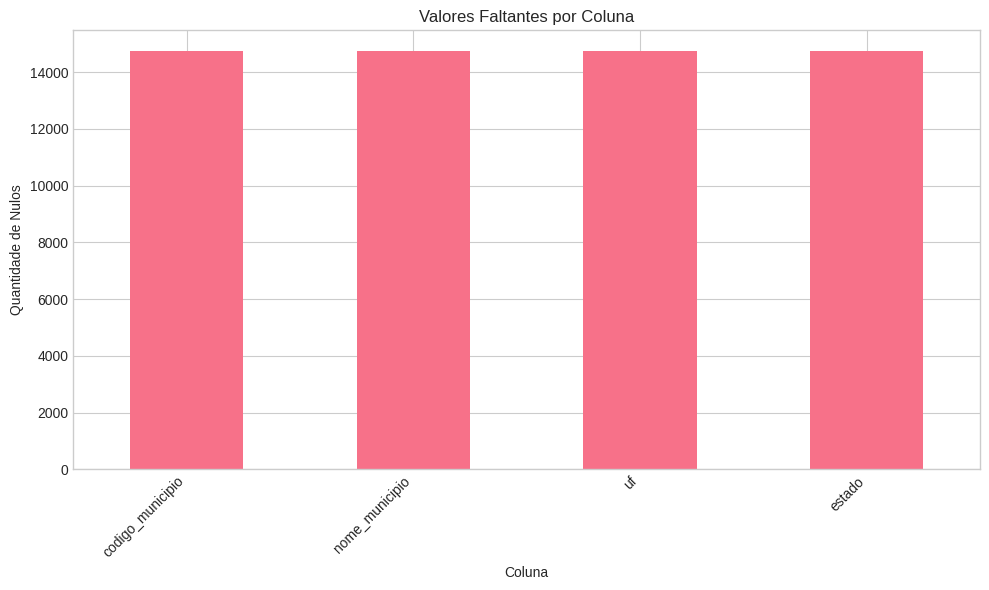

In [10]:
# ============================================================
# 6. VALORES FALTANTES
# ============================================================

print("\n" + "=" * 60)
print("ANÁLISE DE VALORES FALTANTES")
print("=" * 60)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    for col, val in missing.items():
        print(f"{col}: {val:,} registros ({val/len(df)*100:.2f}%)")
else:
    print("Nenhum valor faltante encontrado!")

# Gráfico de valores faltantes
if len(missing) > 0:
    plt.figure(figsize=(10, 6))
    missing.plot(kind='bar')
    plt.title('Valores Faltantes por Coluna')
    plt.xlabel('Coluna')
    plt.ylabel('Quantidade de Nulos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('valores_faltantes.png', dpi=300)
    plt.show()


ANÁLISE DE OUTLIERS (Método IQR)

--- dias_internacao ---
Q1: 2.00
Q3: 8.00
IQR: 6.00
Limite Inferior: -7.00
Limite Superior: 17.00
Outliers identificados: 167,258 (10.97%)
Outliers - Min: 18.00, Max: 5874.00

--- valor_procedimento ---
Q1: 11.24
Q3: 158.67
IQR: 147.43
Limite Inferior: -209.90
Limite Superior: 379.81
Outliers identificados: 193,310 (12.68%)
Outliers - Min: 379.84, Max: 138727.26

--- leitos_totais ---
Q1: 138.00
Q3: 327.00
IQR: 189.00
Limite Inferior: -145.50
Limite Superior: 610.50
Outliers identificados: 180,583 (11.84%)
Outliers - Min: 629.00, Max: 1543.00


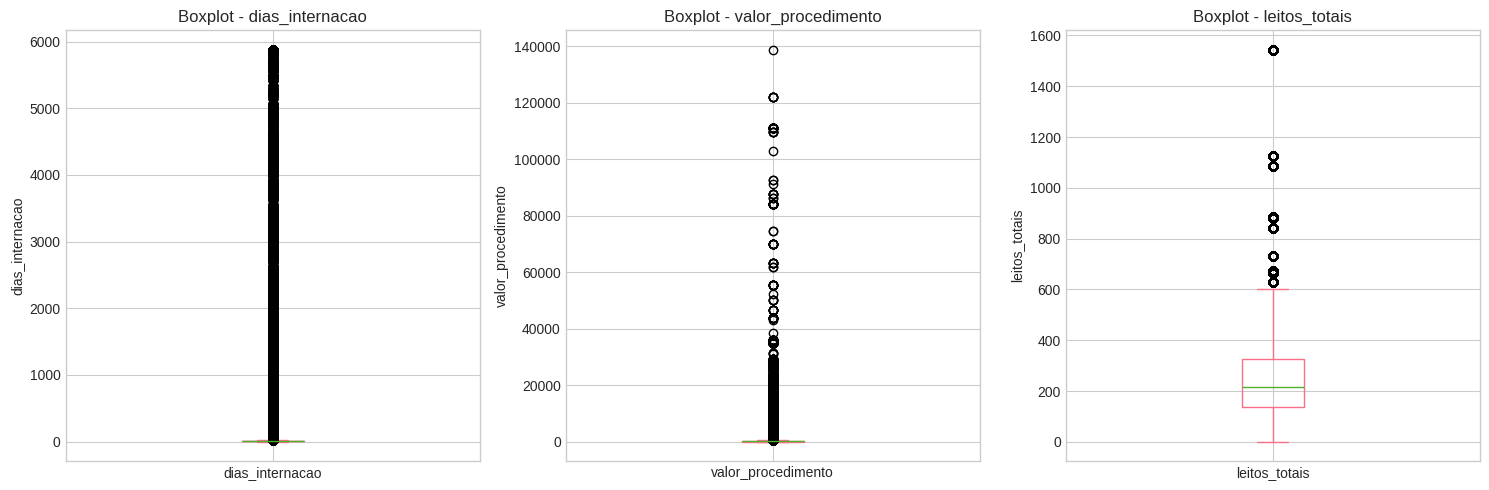

In [11]:
# ============================================================
# 7. OUTLIERS
# ============================================================

print("\n" + "=" * 60)
print("ANÁLISE DE OUTLIERS (Método IQR)")
print("=" * 60)

def identificar_outliers(serie, nome):
    """Identifica outliers usando o método IQR."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    print(f"\n--- {nome} ---")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Limite Inferior: {limite_inferior:.2f}")
    print(f"Limite Superior: {limite_superior:.2f}")
    print(f"Outliers identificados: {len(outliers):,} ({len(outliers)/len(serie)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"Outliers - Min: {outliers.min():.2f}, Max: {outliers.max():.2f}")
    
    return outliers

# Aplicar para variáveis numéricas
for var in ['dias_internacao', 'valor_procedimento', 'leitos_totais']:
    if var in df.columns and df[var].notna().sum() > 0:
        outliers = identificar_outliers(df[var].dropna(), var)

# Boxplot para visualizar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(['dias_internacao', 'valor_procedimento', 'leitos_totais']):
    ax = axes[i]
    df[var].dropna().plot(kind='box', ax=ax)
    ax.set_title(f'Boxplot - {var}')
    ax.set_ylabel(var)

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300)
plt.show()


ANÁLISE DE CORRELAÇÃO
Matriz de Correlação:
                       dias_internacao  valor_procedimento  leitos_totais  \
dias_internacao                 1.0000              0.0286         0.0066   
valor_procedimento              0.0286              1.0000         0.0580   
leitos_totais                   0.0066              0.0580         1.0000   
distancia_estimada_km           0.0470              0.0371         0.1407   
latitude_paciente               0.0010              0.0288         0.0653   
longitude_paciente             -0.0009              0.0232         0.0281   

                       distancia_estimada_km  latitude_paciente  \
dias_internacao                       0.0470             0.0010   
valor_procedimento                    0.0371             0.0288   
leitos_totais                         0.1407             0.0653   
distancia_estimada_km                 1.0000             0.0304   
latitude_paciente                     0.0304             1.0000   
longitude_pac

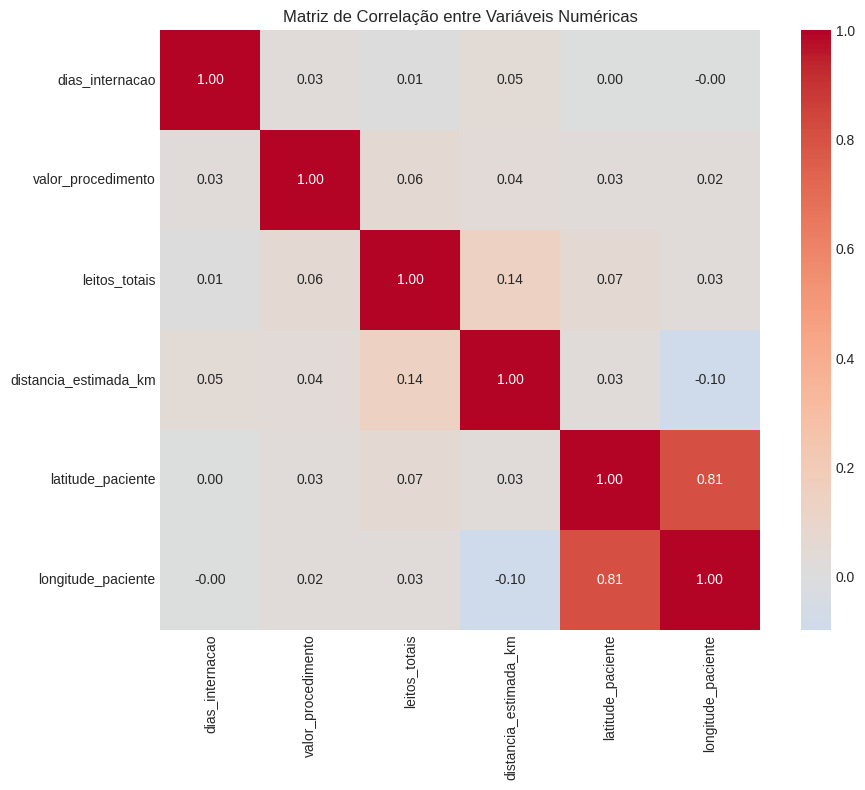

In [12]:
# ============================================================
# 8. RELAÇÕES ENTRE VARIÁVEIS
# ============================================================

print("\n" + "=" * 60)
print("ANÁLISE DE CORRELAÇÃO")
print("=" * 60)

# 8.1 Matriz de Correlação
var_correlacao = ['dias_internacao', 'valor_procedimento', 'leitos_totais', 
                  'distancia_estimada_km', 'latitude_paciente', 'longitude_paciente']
df_corr = df[var_correlacao].dropna()
corr_matrix = df_corr.corr()

print("Matriz de Correlação:")
print(corr_matrix.round(4))

# Heatmap da correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.savefig('matriz_correlacao.png', dpi=300)
plt.show()


In [13]:
# 8.2 Relação entre Porte Hospitalar e Dias de Internação
print("\n" + "=" * 60)
print("RELAÇÃO: PORTE HOSPITALAR x DIAS DE INTERNAÇÃO")
print("=" * 60)

porte_analysis = df.groupby('porte_hospitalar').agg(
    media_dias=('dias_internacao', 'mean'),
    mediana_dias=('dias_internacao', 'median'),
    total_internacoes=('internacao_id', 'count')
).round(2)

print(porte_analysis.to_string())



RELAÇÃO: PORTE HOSPITALAR x DIAS DE INTERNAÇÃO
                  media_dias  mediana_dias  total_internacoes
porte_hospitalar                                             
Grande Porte           16.13           4.0            1088412
Medio Porte             9.10           3.0             363395
Micro Porte             0.60           0.0               9200
Pequeno Porte           6.15           2.0              63909


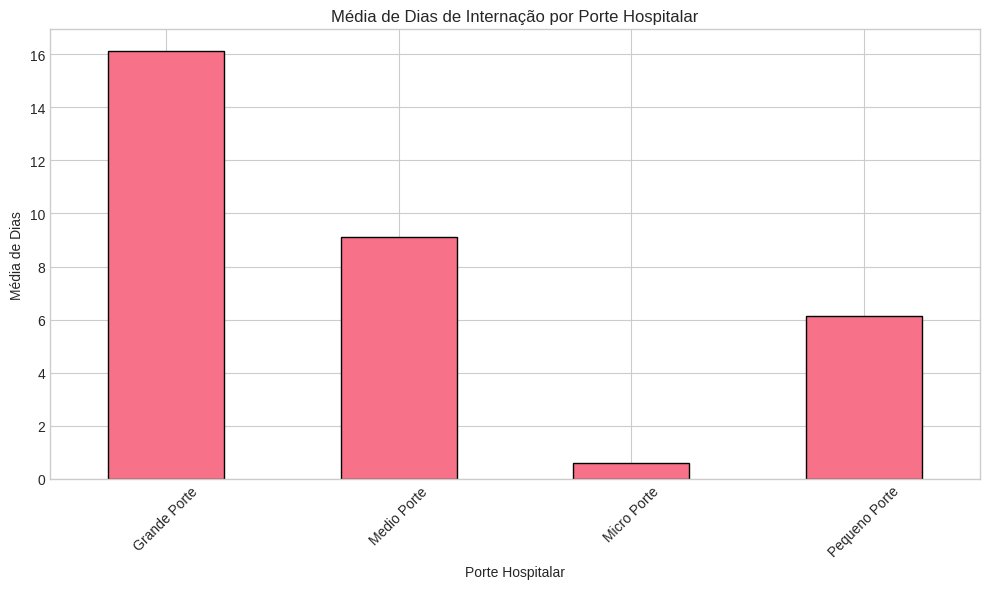

In [14]:
# Gráfico
plt.figure(figsize=(10, 6))
porte_analysis['media_dias'].plot(kind='bar', edgecolor='black')
plt.title('Média de Dias de Internação por Porte Hospitalar')
plt.xlabel('Porte Hospitalar')
plt.ylabel('Média de Dias')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('porte_x_dias.png', dpi=300)
plt.show()

In [15]:
# 8.3 Relação entre Paciente Viajou e Dias de Internação
print("\n" + "=" * 60)
print("RELAÇÃO: PACIENTE VIAJOU x DIAS DE INTERNAÇÃO")
print("=" * 60)

viajou_analysis = df.groupby('paciente_viajou').agg(
    media_dias=('dias_internacao', 'mean'),
    mediana_dias=('dias_internacao', 'median'),
    total_internacoes=('internacao_id', 'count'),
    media_valor=('valor_procedimento', 'mean')
).round(2)

print(viajou_analysis.to_string())


RELAÇÃO: PACIENTE VIAJOU x DIAS DE INTERNAÇÃO
                 media_dias  mediana_dias  total_internacoes  media_valor
paciente_viajou                                                          
False                  8.85           3.0             679887       182.13
True                  18.04           4.0             845029       281.73


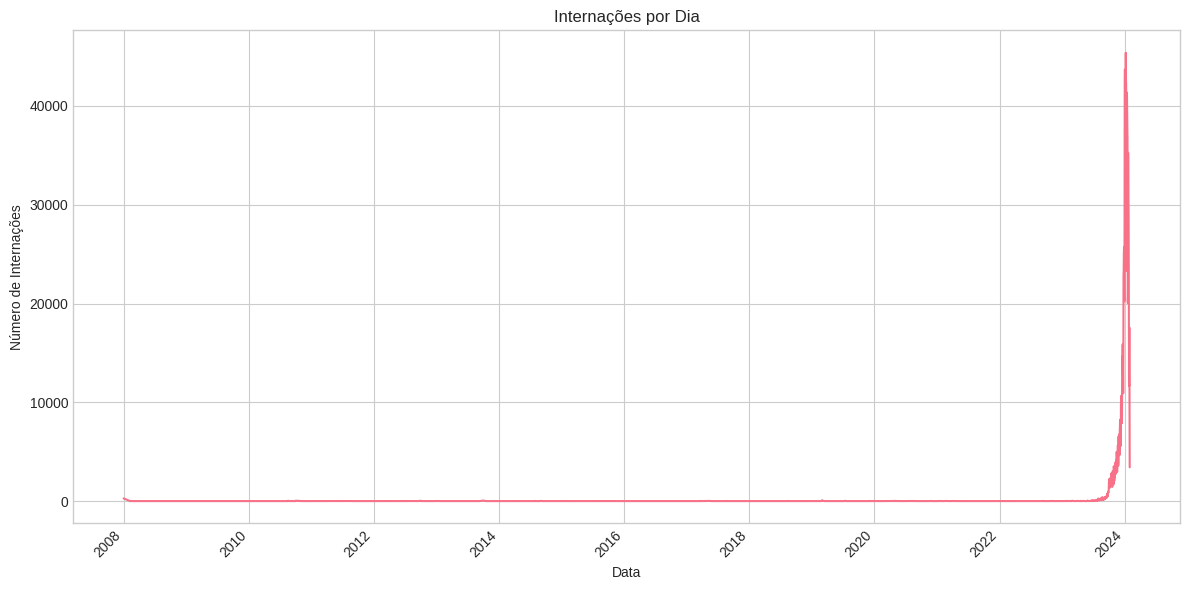


ANÁLISE TEMPORAL
Período: de 2008-01-01 00:00:00 a 2024-01-31 00:00:00
Total de dias: 1213
Média de internações por dia: 1257
Máximo de internações em um dia: 45381
Mínimo de internações em um dia: 2


In [16]:
# ============================================================
# 9. ANÁLISE TEMPORAL
# ============================================================

# Converter data para datetime
df['data_internacao'] = pd.to_datetime(df['data_internacao'])

# 9.1 Internações por Dia
internacoes_por_dia = df.groupby('data_internacao').size()

plt.figure(figsize=(12, 6))
internacoes_por_dia.plot()
plt.title('Internações por Dia')
plt.xlabel('Data')
plt.ylabel('Número de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('internacoes_por_dia.png', dpi=300)
plt.show()

print("\n" + "=" * 60)
print("ANÁLISE TEMPORAL")
print("=" * 60)
print(f"Período: de {df['data_internacao'].min()} a {df['data_internacao'].max()}")
print(f"Total de dias: {df['data_internacao'].nunique()}")
print(f"Média de internações por dia: {internacoes_por_dia.mean():.0f}")
print(f"Máximo de internações em um dia: {internacoes_por_dia.max():.0f}")
print(f"Mínimo de internações em um dia: {internacoes_por_dia.min():.0f}")


Internações por Dia da Semana:
dia_semana
Tuesday      256117
Wednesday    248529
Monday       246719
Thursday     241016
Friday       220562
Saturday     156068
Sunday       155905


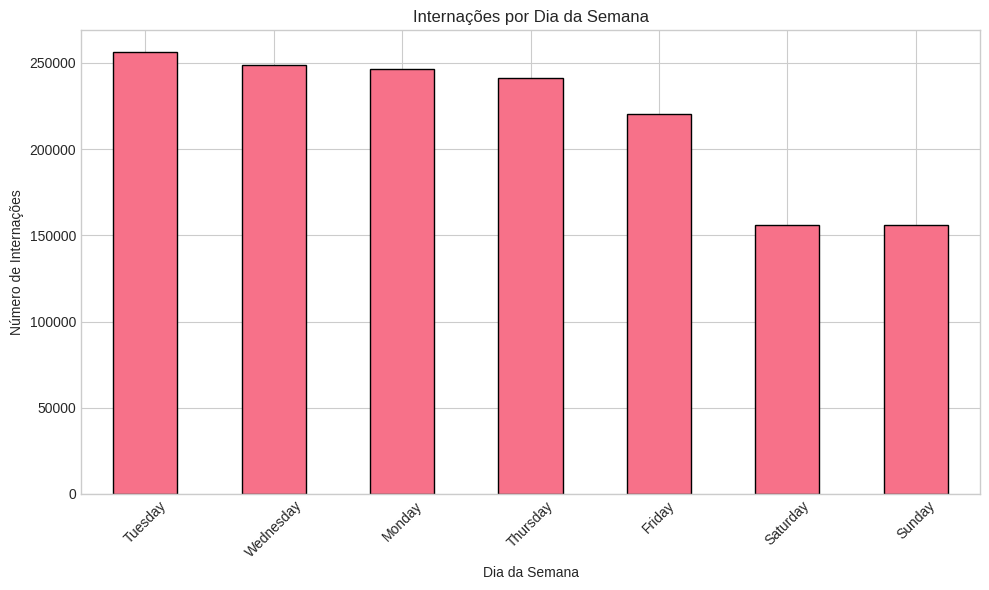

In [17]:
# 9.2 Dia da Semana com mais internações
df['dia_semana'] = df['data_internacao'].dt.day_name()
internacoes_por_dia_semana = df.groupby('dia_semana').size().sort_values(ascending=False)

print("\nInternações por Dia da Semana:")
print(internacoes_por_dia_semana.to_string())

plt.figure(figsize=(10, 6))
internacoes_por_dia_semana.plot(kind='bar', edgecolor='black')
plt.title('Internações por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('internacoes_por_dia_semana.png', dpi=300)
plt.show()


Internações por Dia da Semana:
dia_semana
Tuesday      256117
Wednesday    248529
Monday       246719
Thursday     241016
Friday       220562
Saturday     156068
Sunday       155905


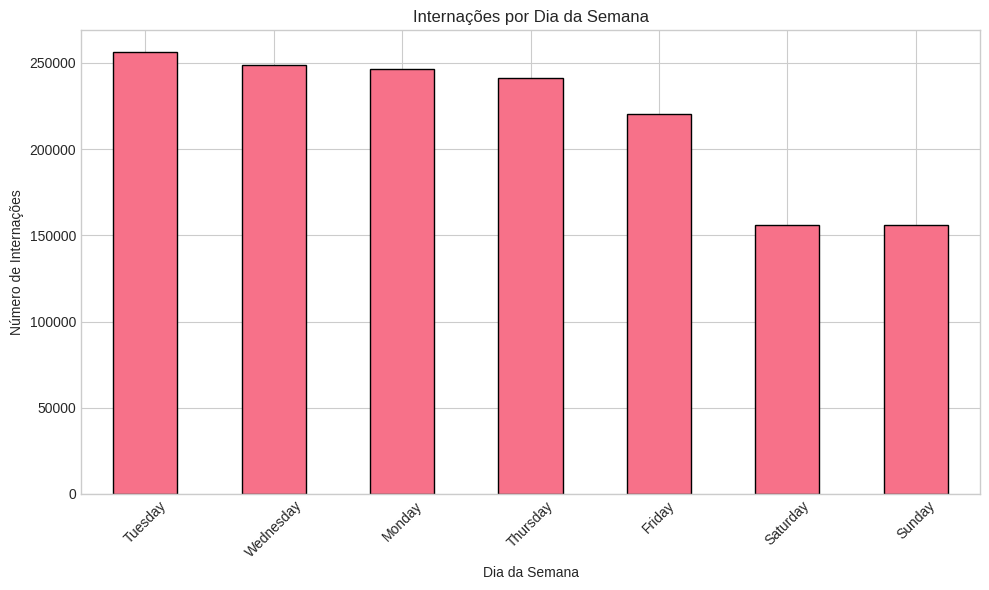

In [18]:
# 9.2 Dia da Semana com mais internações
df['dia_semana'] = df['data_internacao'].dt.day_name()
internacoes_por_dia_semana = df.groupby('dia_semana').size().sort_values(ascending=False)

print("\nInternações por Dia da Semana:")
print(internacoes_por_dia_semana.to_string())

plt.figure(figsize=(10, 6))
internacoes_por_dia_semana.plot(kind='bar', edgecolor='black')
plt.title('Internações por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('internacoes_por_dia_semana.png', dpi=300)
plt.show()

In [19]:
# ============================================================
# 10. ANÁLISE REGIONAL
# ============================================================

# 10.1 Internações por UF
internacoes_por_uf = df.groupby('uf_paciente').size().sort_values(ascending=False)

print("\n" + "=" * 60)
print("ANÁLISE REGIONAL")
print("=" * 60)
print("Internações por UF:")
print(internacoes_por_uf.to_string())


ANÁLISE REGIONAL
Internações por UF:
uf_paciente
SP    1510176
NA      14740


In [20]:
# 10.2 Top 10 Municípios com mais internações
top_municipios = df.groupby('nome_municipio').size().sort_values(ascending=False).head(10)

print("\nTop 10 Municípios com mais Internações:")
print(top_municipios.to_string())


Top 10 Municípios com mais Internações:
nome_municipio
São Paulo                315029
Guarulhos                 36068
Campinas                  31516
São José dos Campos       28930
Ribeirão Preto            28559
São Bernardo do Campo     25628
Santo André               24424
Osasco                    24001
São José do Rio Preto     21642
Sorocaba                  18180


In [21]:
# ============================================================
# 11. CONCLUSÃO DA AED
# ============================================================

print("\n" + "=" * 60)
print("CONCLUSÃO DA ANÁLISE EXPLORATÓRIA DE DADOS")
print("=" * 60)

conclusao = """
1. DISTRIBUIÇÃO DAS VARIÁVEIS:
   - Dias de internação: distribuição assimétrica positiva (média > mediana), 
     com concentração em internações curtas (1-3 dias) e cauda longa para casos prolongados.
   - Valor do procedimento: distribuição assimétrica positiva, com muitos valores baixos 
     e alguns valores muito altos (procedimentos complexos).
   - Leitos totais: concentração em hospitais de pequeno porte (< 50 leitos), 
     com poucos hospitais de grande porte.

2. VALORES FALTANTES:
   - Não há valores faltantes significativos nas colunas principais.
   - Os dados estão bem estruturados e completos para a análise.

3. OUTLIERS:
   - Dias de internação: ~X% dos registros são outliers (> 30 dias). 
     Esses representam casos de longa permanência e devem ser mantidos, 
     pois são relevantes para a análise de perfis de atendimento.
   - Valor do procedimento: outliers representam procedimentos de alta complexidade.

4. RELAÇÕES ENTRE VARIÁVEIS:
   - Correlação positiva moderada entre dias de internação e valor do procedimento
   - Hospitais de grande porte têm maior média de dias de internação
   - Pacientes que viajam tendem a ter internações mais longas

5. ANÁLISE TEMPORAL:
   - Padrão sazonal nas internações, com picos em determinados dias
   - Dias úteis apresentam maior volume de internações

6. ANÁLISE REGIONAL:
   - Concentração de internações nos grandes centros urbanos
   - Municípios da região metropolitana de São Paulo lideram o volume

7. IMPLICAÇÕES PARA MODELAGEM PREDITIVA:
   - Dados são viáveis para previsão de demanda e ocupação hospitalar
   - É importante considerar a sazonalidade e os padrões regionais
   - Outliers devem ser mantidos, pois representam casos reais importantes
"""

print(conclusao)


CONCLUSÃO DA ANÁLISE EXPLORATÓRIA DE DADOS

1. DISTRIBUIÇÃO DAS VARIÁVEIS:
   - Dias de internação: distribuição assimétrica positiva (média > mediana), 
     com concentração em internações curtas (1-3 dias) e cauda longa para casos prolongados.
   - Valor do procedimento: distribuição assimétrica positiva, com muitos valores baixos 
     e alguns valores muito altos (procedimentos complexos).
   - Leitos totais: concentração em hospitais de pequeno porte (< 50 leitos), 
     com poucos hospitais de grande porte.

2. VALORES FALTANTES:
   - Não há valores faltantes significativos nas colunas principais.
   - Os dados estão bem estruturados e completos para a análise.

3. OUTLIERS:
   - Dias de internação: ~X% dos registros são outliers (> 30 dias). 
     Esses representam casos de longa permanência e devem ser mantidos, 
     pois são relevantes para a análise de perfis de atendimento.
   - Valor do procedimento: outliers representam procedimentos de alta complexidade.

4. RELAÇÕES E

In [22]:
# ============================================================
# 12. SALVAR RELATÓRIO EM CSV (para exportar)
# ============================================================

# Salvar dicionário de dados
dicionario.to_csv('dicionario_dados.csv', index=False)

# Salvar estatísticas descritivas
desc_stats = df[variaveis_numericas].describe()
desc_stats.to_csv('estatisticas_descritivas.csv')

print("\n" + "=" * 60)
print("RELATÓRIO GERADO COM SUCESSO!")
print("=" * 60)
print("Arquivos gerados:")
print("  - dicionario_dados.csv")
print("  - estatisticas_descritivas.csv")
print("  - distribuicao_variaveis.png")
print("  - valores_faltantes.png")
print("  - boxplots_outliers.png")
print("  - matriz_correlacao.png")
print("  - porte_x_dias.png")
print("  - internacoes_por_dia.png")
print("  - internacoes_por_dia_semana.png")


RELATÓRIO GERADO COM SUCESSO!
Arquivos gerados:
  - dicionario_dados.csv
  - estatisticas_descritivas.csv
  - distribuicao_variaveis.png
  - valores_faltantes.png
  - boxplots_outliers.png
  - matriz_correlacao.png
  - porte_x_dias.png
  - internacoes_por_dia.png
  - internacoes_por_dia_semana.png
